In [87]:
# included libraries, all used
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# load in the dataset
csv_path = "ClaMP_Raw-5184.csv" 
df = pd.read_csv(csv_path)

print("CLaMP Dataset")
df.head()

CLaMP Dataset


,e_magic,e_cblp,e_cp,e_crlc,e_cparhdr,e_minalloc,e_maxalloc,e_ss,e_sp,e_csum,...,CheckSum,Subsystem,DllCharacteristics,SizeOfStackReserve,SizeOfStackCommit,SizeOfHeapReserve,SizeOfHeapCommit,LoaderFlags,NumberOfRvaAndSizes,class
0,23117,144,3,0,4,0,65535,0,184,0,...,1194954,3,64,1048576,4096,1048576,4096,0,16,0
1,23117,144,3,0,4,0,65535,0,184,0,...,0,2,0,1048576,4096,1048576,4096,0,16,0
2,23117,144,3,0,4,0,65535,0,184,0,...,67688,2,320,1048576,4096,1048576,4096,0,16,0
3,23117,144,3,0,4,0,65535,0,184,0,...,113668,2,1344,1048576,4096,1048576,4096,0,16,0
4,23117,144,3,0,4,0,65535,0,184,0,...,69089,2,33088,262144,8192,1048576,4096,0,16,0


In [88]:
print("Shape of CLaMP")
print(df.shape)

print("\nDataset Info ")
df.info()

Shape of CLaMP
(5184, 56)

Dataset Info 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5184 entries, 0 to 5183
Data columns (total 56 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   e_magic                      5184 non-null   int64  
 1   e_cblp                       5184 non-null   int64  
 2   e_cp                         5184 non-null   int64  
 3   e_crlc                       5184 non-null   int64  
 4   e_cparhdr                    5184 non-null   int64  
 5   e_minalloc                   5184 non-null   int64  
 6   e_maxalloc                   5184 non-null   int64  
 7   e_ss                         5184 non-null   int64  
 8   e_sp                         5184 non-null   int64  
 9   e_csum                       5184 non-null   int64  
 10  e_ip                         5184 non-null   int64  
 11  e_cs                         5184 non-null   int64  
 12  e_lfarlc                     5184 n

In [89]:
#the 10 overlapping features
clamp_features = [
    'NumberOfSections', 'Characteristics', 'Magic', 'MajorLinkerVersion',
    'SizeOfCode', 'AddressOfEntryPoint', 'ImageBase', 'SizeOfImage',
    'DllCharacteristics', 'SizeOfStackReserve'
]

# Separate features, x
# ground truth target, y
x = df[clamp_features]
y = df['class']

print("Shape configurations:")
print(f"x shape: {x.shape}")
print(f"y shape: {y.shape}")

print("\nLabel head preview:")
print(y.head())

Shape configurations:
x shape: (5184, 10)
y shape: (5184,)

Label head preview:
0    0
1    0
2    0
3    0
4    0
Name: class, dtype: int64


In [90]:
# splitting 0.2 for testing
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=10, stratify=y
)

print("Split Data:")
print(f"len(x_train): {len(x_train)}")
print(f"len(x_test):  {len(x_test)}")
print(f"x_train.shape: {x_train.shape}")
print(f"x_test.shape:  {x_test.shape}")
print(f"y_train.shape: {y_train.shape}")
print(f"y_test.shape:  {y_test.shape}")

Split Data:
len(x_train): 4147
len(x_test):  1037
x_train.shape: (4147, 10)
x_test.shape:  (1037, 10)
y_train.shape: (4147,)
y_test.shape:  (1037,)


In [91]:
print("Length of Split Data:")
print(f"{len(x)} - number of elements in the entire dataset.")
print(f"{len(x_train)} - number of training elements.")
print(f"{len(x_test)} - number of testing elements.")
print(f"{len(x_train) + len(x_test)} - sum of training and testing elements.")

Length of Split Data:
5184 - number of elements in the entire dataset.
4147 - number of training elements.
1037 - number of testing elements.
5184 - sum of training and testing elements.


In [92]:
print("Training Summary")
display(x_train.describe())

print("\nTesting Summary")
display(x_test.describe())

Training Summary


,NumberOfSections,Characteristics,Magic,MajorLinkerVersion,SizeOfCode,AddressOfEntryPoint,ImageBase,SizeOfImage,DllCharacteristics,SizeOfStackReserve
count,4147.000000,4147.000000,4147.000000,4147.000000,4.147000e+03,4.147000e+03,4.147000e+03,4.147000e+03,4147.000000,4.147000e+03
mean,4.671329,4562.393779,266.356161,7.571739,1.046456e+06,1.650533e+05,1.439302e+08,5.763187e+05,9499.536774,2.033067e+06
std,1.972130,8180.800134,13.097016,6.860533,5.575917e+07,1.067301e+06,3.516681e+08,2.537513e+06,14845.855141,4.736844e+06
min,1.000000,34.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00
25%,4.000000,258.000000,267.000000,6.000000,1.177600e+04,7.105500e+03,4.194304e+06,8.192000e+04,0.000000,1.048576e+06
50%,5.000000,271.000000,267.000000,8.000000,3.686400e+04,1.869500e+04,4.194304e+06,1.392640e+05,0.000000,1.048576e+06
75%,5.000000,8450.000000,267.000000,9.000000,1.351680e+05,7.376500e+04,2.684355e+08,3.440640e+05,32768.000000,1.048576e+06
max,34.000000,41358.000000,267.000000,242.000000,3.590647e+09,4.240387e+07,2.133656e+09,8.125235e+07,37184.000000,3.355443e+07



Testing Summary


,NumberOfSections,Characteristics,Magic,MajorLinkerVersion,SizeOfCode,AddressOfEntryPoint,ImageBase,SizeOfImage,DllCharacteristics,SizeOfStackReserve
count,1037.000000,1037.000000,1037.000000,1037.000000,1.037000e+03,1.037000e+03,1.037000e+03,1.037000e+03,1037.000000,1.037000e+03
mean,4.642237,4714.034716,266.742527,7.594021,1.804504e+05,1.295993e+05,1.571896e+08,4.868837e+05,9298.121504,1.815075e+06
std,1.727662,8256.894481,8.291286,8.836573,5.749316e+05,3.989357e+05,3.599811e+08,2.096077e+06,14763.311653,4.050324e+06
min,1.000000,258.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00
25%,4.000000,258.000000,267.000000,6.000000,1.382400e+04,7.085000e+03,4.194304e+06,8.601600e+04,0.000000,1.048576e+06
50%,5.000000,271.000000,267.000000,8.000000,3.891200e+04,2.018700e+04,4.194304e+06,1.392640e+05,0.000000,1.048576e+06
75%,5.000000,8450.000000,267.000000,9.000000,1.402880e+05,8.112700e+04,2.684355e+08,3.481600e+05,32768.000000,1.048576e+06
max,20.000000,41358.000000,267.000000,255.000000,1.178419e+07,5.718992e+06,2.081554e+09,6.052659e+07,34240.000000,3.355443e+07


In [93]:
print("Entire CLaMP dataset summary")
with pd.option_context('display.max_columns', None):
    display(df.describe())

Entire CLaMP dataset summary


,e_magic,e_cblp,e_cp,e_crlc,e_cparhdr,e_minalloc,e_maxalloc,e_ss,e_sp,e_csum,e_ip,e_cs,e_lfarlc,e_ovno,e_res,e_oemid,e_oeminfo,e_res2,e_lfanew,Machine,NumberOfSections,CreationYear,PointerToSymbolTable,NumberOfSymbols,SizeOfOptionalHeader,Characteristics,Magic,MajorLinkerVersion,MinorLinkerVersion,SizeOfCode,SizeOfInitializedData,SizeOfUninitializedData,AddressOfEntryPoint,BaseOfCode,BaseOfData,ImageBase,SectionAlignment,FileAlignment,MajorOperatingSystemVersion,MinorOperatingSystemVersion,MajorImageVersion,MinorImageVersion,MajorSubsystemVersion,MinorSubsystemVersion,SizeOfImage,SizeOfHeaders,CheckSum,Subsystem,DllCharacteristics,SizeOfStackReserve,SizeOfStackCommit,SizeOfHeapReserve,SizeOfHeapCommit,LoaderFlags,NumberOfRvaAndSizes,class
count,5184.0,5184.000000,5184.000000,5184.0,5184.000000,5184.000000,5184.000000,5184.000000,5184.000000,5184.000000,5184.000000,5184.000000,5184.000000,5184.000000,0.0,5184.000000,5184.000000,0.0,5184.000000,5184.000000,5184.000000,5184.000000,5.184000e+03,5184.000000,5184.000000,5184.000000,5184.000000,5184.000000,5184.000000,5.184000e+03,5.184000e+03,5.184000e+03,5.184000e+03,5.184000e+03,5.184000e+03,5.184000e+03,5184.000000,5184.000000,5184.000000,5184.000000,5184.000000,5184.000000,5184.000000,5184.000000,5.184000e+03,5.184000e+03,5.184000e+03,5184.000000,5184.000000,5.184000e+03,5.184000e+03,5.184000e+03,5184.000000,5.184000e+03,5184.000000,5184.000000
mean,23117.0,145.966435,2.938657,0.0,3.971836,1.855131,65153.373264,12.638889,195.785880,0.000772,10.521798,23.466628,63.617477,1.750386,NaN,0.154514,0.004244,NaN,223.262346,404.320216,4.665509,2008.881944,1.016907e+03,6.318480,224.033951,4592.727816,266.433449,7.576196,5.385417,8.732213e+05,2.764234e+05,2.644292e+05,1.579612e+05,4.673180e+04,2.269867e+05,1.465826e+08,4260.888889,1191.061728,4.606289,0.415123,107.669753,98.312114,4.581983,0.355517,5.584282e+05,4.060579e+03,2.321815e+06,2.138696,9459.245949,1.989460e+06,1.038919e+04,2.089821e+06,5749.728395,4.257385e+04,15.963927,0.517554
std,0.0,512.429759,1.991420,0.0,0.333333,57.004873,4937.431418,910.000000,907.821623,0.034015,523.044693,1015.080827,4.934814,6.515702,NaN,6.421782,0.177831,NaN,48.172425,1567.985533,1.925588,6.086738,4.355858e+04,151.743322,0.736316,8195.503468,12.287280,7.297804,10.603131,4.987198e+07,2.101902e+06,1.029203e+07,9.712000e+05,8.534107e+05,1.081683e+06,3.533514e+08,1010.246730,1409.079729,1.016878,0.870847,1556.161344,1545.577552,0.767761,0.842598,2.455638e+06,4.893776e+04,8.449318e+07,0.535320,14828.177858,4.608162e+06,7.482986e+04,4.424085e+06,6847.201569,1.747203e+06,0.749333,0.499740
min,23117.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,NaN,12.000000,332.000000,1.000000,1970.000000,0.000000e+00,0.000000,224.000000,34.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000
25%,23117.0,144.000000,3.000000,0.0,4.000000,0.000000,65535.000000,0.000000,184.000000,0.000000,0.000000,0.000000,64.000000,0.000000,NaN,0.000000,0.000000,NaN,208.000000,332.000000,4.000000,2009.000000,0.000000e+00,0.000000,224.000000,258.000000,267.000000,6.000000,0.000000,1.228800e+04,1.228800e+04,0.000000e+00,7.104000e+03,4.096000e+03,1.638400e+04,4.194304e+06,4096.000000,512.000000,4.000000,0.000000,0.000000,0.000000,4.000000,0.000000,8.192000e+04,1.024000e+03,0.000000e+00,2.000000,0.000000,1.048576e+06,4.096000e+03,1.048576e+06,4096.000000,0.000000e+00,16.000000,0.000000
50%,23117.0,144.000000,3.000000,0.0,4.000000,0.000000,65535.000000,0.000000,184.000000,0.000000,0.000000,0.000000,64.000000,0.000000,NaN,0.000000,0.000000,NaN,232.000000,332.000000,5.000000,2010.000000,0.000000e+00,0.000000,224.000000,271.000000,267.00

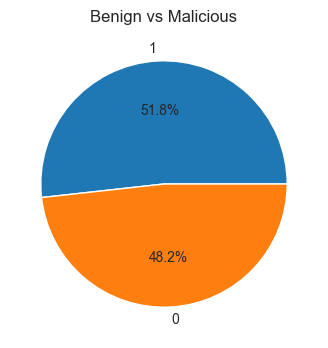

In [94]:
# Seaborn benign vs malicious pie chart
sns.set_style('whitegrid') 
plt.figure(figsize=(6, 4)) 
plt.pie(df['class'].value_counts(), labels=df['class'].value_counts().index, autopct='%1.1f%%')
plt.title('Benign vs Malicious')
plt.show()

In [104]:
#Scaling
scaler = MinMaxScaler(feature_range=(0, 1))
Xtrainscaled = scaler.fit_transform(x_train)
Xtestscaled = scaler.transform(x_test)

print("Feature scaling done")
print(f"Scaled Train Bounds: Min={Xtrainscaled.min():.1f}, Max={Xtrainscaled.max():.1f}")

Feature scaling done
Scaled Train Bounds: Min=0.0, Max=1.0


In [105]:
linear_svm = SVC(kernel='linear', C=1.0, random_state=42)
linear_svm.fit(Xtrainscaled, y_train)

#Testinh
preds = linear_svm.predict(Xtestscaled)
acc = accuracy_score(y_test, preds)
auc = roc_auc_score(y_test, preds)

# Report

print("             CLASSICAL SVM RESULTS")

print(f"\nRESULTS: LINEAR KERNEL SVM")
print(f"Overall Accuracy: {linear_acc:.4f}")

print("\nClassification Matrix Detail:")
print(classification_report(y_test, linear_preds, target_names=['Benign (0)', 'Malware (1)']))


             CLASSICAL SVM RESULTS

RESULTS: LINEAR KERNEL SVM
Overall Accuracy: 0.8177

Classification Matrix Detail:
              precision    recall  f1-score   support

  Benign (0)       0.78      0.87      0.82       500
 Malware (1)       0.87      0.77      0.81       537

    accuracy                           0.82      1037
   macro avg       0.82      0.82      0.82      1037
weighted avg       0.82      0.82      0.82      1037

